In [1]:
# This is our very first cell in the Jupyter Notebook.
# We can run this cell to make sure the Python kernel is working.
print("Hello, Jupyter! The analysis can now begin.")

Hello, Jupyter! The analysis can now begin.


In [2]:
import pandas as pd
file_path = '../data/IMDB Dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully into a Pandas DataFrame!")

Dataset loaded successfully into a Pandas DataFrame!


In [3]:
display(df.head())
display(df.shape)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


(50000, 2)

In [4]:
# To check for missing values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
def to_lowercase(text):
    return text.lower()

example="THIS was a GREAT Movie"
cleaned=to_lowercase(example)
print(example)
print(cleaned)

THIS was a GREAT Movie
this was a great movie


In [7]:
#make all the reviews in lowercase
df['review']=df['review'].apply(to_lowercase)
print("Dataframe after apllying lowercase function")
df.head()

Dataframe after apllying lowercase function


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [8]:
# using regex to remove html tags
import re

def remove_html_tags(text):
    pattern=re.compile('<.*?>')
    return pattern.sub('',text)

example_text_with_html = "this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching."
cleaned_text = remove_html_tags(example_text_with_html)

print(example_text_with_html)
print(cleaned_text)

this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching.
this was an amazing movie. i loved it! totally worth watching.


In [9]:
# applying regex to df
df['review']=df['review'].apply(remove_html_tags)
print("Dataframe after applying function")
print(df.head())

Dataframe after applying function
                                              review sentiment
0  one of the other reviewers has mentioned that ...  positive
1  a wonderful little production. the filming tec...  positive
2  i thought this was a wonderful way to spend ti...  positive
3  basically there's a family where a little boy ...  negative
4  petter mattei's "love in the time of money" is...  positive


In [10]:
# removing punctuations
def remove_punctuation(text):
    return re.sub(r'[^a-z0-9\s]', ' ', text).strip()
    
example_text_with_punc = "wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'."
cleaned_text = remove_punctuation(example_text_with_punc)
print(example_text_with_punc)
print(cleaned_text)

wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'.
wow    this movie was  amazing    10 10   i d say it s a  must see


In [11]:
# remove punctuation from df
df['review']=df['review'].apply(remove_punctuation)
print("Applied function to Dataframe")
print(df.head())

Applied function to Dataframe
                                              review sentiment
0  one of the other reviewers has mentioned that ...  positive
1  a wonderful little production  the filming tec...  positive
2  i thought this was a wonderful way to spend ti...  positive
3  basically there s a family where a little boy ...  negative
4  petter mattei s  love in the time of money  is...  positive


In [12]:
# removing natural words like he, she, the, it as the create noise and are not usweful for semantic analysis which are known as stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Varad
[nltk_data]     Dalvi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# identifying stopwords and storing them in list and removing duplicates using by converting to set
from nltk.corpus import stopwords

english_stopwords_list=stopwords.words('english')
print("First 10 stopwords from NLTK list")
print(english_stopwords_list[:10])
print("\n" + "="*50 + "\n")

stopwords_set=set(english_stopwords_list)
print(f"We have successfully loaded {len(stopwords_set)} English stopwords into a highly efficient set.")

First 10 stopwords from NLTK list
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


We have successfully loaded 198 English stopwords into a highly efficient set.


In [14]:
def tokenize_and_remove_stopwords(text):
    tokens=text.split()
    cleaned_tokens=[token for token in tokens if token not in stopwords_set]
    return cleaned_tokens

example_sentence = "this movie is just a brilliant and beautiful production"
cleaned_tokens_list = tokenize_and_remove_stopwords(example_sentence)

print("Original Sentence:", example_sentence)
print("Tokens after Stopword Removal:", cleaned_tokens_list)

Original Sentence: this movie is just a brilliant and beautiful production
Tokens after Stopword Removal: ['movie', 'brilliant', 'beautiful', 'production']


In [15]:
# applying to dataframe
df['review']=df['review'].apply(tokenize_and_remove_stopwords)
print("Dataframe after tokenization and stopwords removal")
display(df.head())

Dataframe after tokenization and stopwords removal


,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, thinks,...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [16]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Varad
[nltk_data]     Dalvi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
# Lemmatization: Finding root word. eg: Movies lemma is movie
from nltk.stem import WordNetLemmatizer

lemmatizer=WordNetLemmatizer()
print(f"The lemma for 'running' is: {lemmatizer.lemmatize('running')}")
print(f"The lemma for 'movies' is: {lemmatizer.lemmatize('movies')}")
# It treats all words as nouns so running is not changed

The lemma for 'running' is: running
The lemma for 'movies' is: movie


In [18]:
def lemmatize_tokens(tokens):
    lemmatized_tokens=[lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

example_tokens = ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
lemmatized_example = lemmatize_tokens(example_tokens)

print("Original Tokens:", example_tokens)
print("Lemmatized Tokens:", lemmatized_example)

Original Tokens: ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
Lemmatized Tokens: ['movie', 'are', 'amazing', 'character', 'were', 'running', 'study']


In [19]:
df['review']=df['review'].apply(lemmatize_tokens)
print("DataFrame after applying the lemmatization function:")
df.head()

DataFrame after applying the lemmatization function:


,review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, think, ...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [20]:
def join_tokens(tokens):
    return ' '.join(tokens)

example_lemmatized_tokens = ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
rejoined_text = join_tokens(example_lemmatized_tokens)

print("Original list of tokens:", example_lemmatized_tokens)
print("Rejoined string:", rejoined_text)

Original list of tokens: ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
Rejoined string: movie brilliant beautiful production character scene


In [21]:
df['cleaned_review']=df['review'].apply(join_tokens)
print("DataFrame after final cleaning and rejoining tokens:")
df[['review', 'cleaned_review', 'sentiment']].head()

DataFrame after final cleaning and rejoining tokens:


,review,cleaned_review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode h...,positive
1,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,positive
2,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,positive
3,"[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...,negative
4,"[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...,positive


In [22]:
# Defining features (X) and targets(y) for for machine learning
X=df['cleaned_review']
y=df['sentiment']

print("--- Features (X) ---")
print(X.head())
print("\n" + "="*50 + "\n") # A clean separator
print("--- Target (y) ---")
print(y.head())

--- Features (X) ---
0    one reviewer mentioned watching 1 oz episode h...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically family little boy jake think zombie ...
4    petter mattei love time money visually stunnin...
Name: cleaned_review, dtype: str


--- Target (y) ---
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# splitting data for training and testing
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train ",X_train.shape)
print("Shape of X_test ",X_test.shape)
print("Shape of y_train ",y_train.shape)
print("Shape of y_test ",y_test.shape)


Shape of X_train  (40000,)
Shape of X_test  (10000,)
Shape of y_train  (40000,)
Shape of y_test  (10000,)


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [26]:
# Finding out frequently occuring words
tfidf_vectorizer=TfidfVectorizer(max_features=10000)
print("TfidfVectorizer initialized successfully:")
print(tfidf_vectorizer)

TfidfVectorizer initialized successfully:
TfidfVectorizer(max_features=10000)


In [27]:
# applying TF-IDF on training data
X_train_tfidf=tfidf_vectorizer.fit_transform(X_train)
print("Successfully fitted the vectorizer and transformed the training data.")

Successfully fitted the vectorizer and transformed the training data.


In [28]:
# transforming test data
X_test_tfidf=tfidf_vectorizer.transform(X_test)
print("Successfully transformed the testing data.")

Successfully transformed the testing data.


In [29]:
# verify tf-idf matrix dimensions
print("Shape of the TF-IDF training data matrix (X_train_tfidf):", X_train_tfidf.shape)

print("Shape of the TF-IDF testing data matrix (X_test_tfidf):", X_test_tfidf.shape)

Shape of the TF-IDF training data matrix (X_train_tfidf): (40000, 10000)
Shape of the TF-IDF testing data matrix (X_test_tfidf): (10000, 10000)


In [30]:
# Logistic Regression is a dedicated classification algorithm. 
# It's designed to predict a probability that a given input belongs to a specific category.
from sklearn.linear_model import LogisticRegression

In [31]:
lr_model=LogisticRegression(random_state=42)
print("Logistic Regression model initialized successfully:")
print(lr_model)

Logistic Regression model initialized successfully:
LogisticRegression(random_state=42)


In [32]:
# By calling .fit(), you are instructing the model to perform this entire optimization process and 
# find the best possible set of 10,000 coefficients based on the training data.

lr_model.fit(X_train_tfidf,y_train)
print("The Logistic Regression model has been successfully trained.")

The Logistic Regression model has been successfully trained.


In [33]:
# making predictions using trained model
y_pred=lr_model.predict(X_test_tfidf)

print("First 20 predictions made by the model:")
print(y_pred[:20])

print("\n" + "="*50 + "\n")
print("Comparison of first 5 Predictions vs. Actual Labels:")
print("Predictions:", y_pred[:5])
print("Actuals:    ", y_test.values[:5])

First 20 predictions made by the model:
['negative' 'negative' 'positive' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative' 'negative' 'positive'
 'positive' 'negative' 'positive' 'positive' 'positive' 'positive'
 'positive' 'positive']


Comparison of first 5 Predictions vs. Actual Labels:
Predictions: ['negative' 'negative' 'positive' 'negative' 'negative']
Actuals:     <StringArray>
['negative', 'negative', 'positive', 'negative', 'negative']
Length: 5, dtype: str


In [34]:
from sklearn.metrics import classification_report, confusion_matrix

In [35]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [36]:
cm=confusion_matrix(y_test,y_pred)
print(cm)
# Calculating True Negative (TN), False Positive (FP), False Negative (FN), True Positive (TP)

[[4417  583]
 [ 474 4526]]


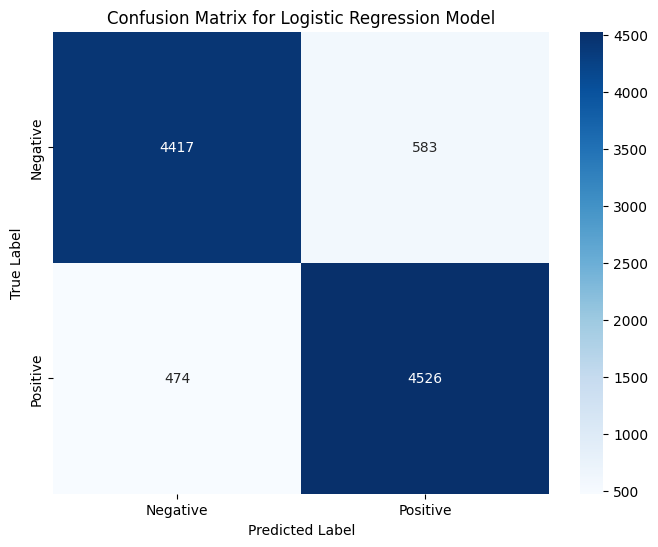

In [37]:
# creating heatmap to visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names=['Negative','Positive']
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')

plt.show()

In [38]:
import joblib

In [39]:
# saving trained model using joblib
model_filename='lr_model.pkl'

joblib.dump(lr_model,model_filename)
print(f"Model saved successfully to '{model_filename}'")

vectorizer_filename='tfidf_vectorizer.pkl'
joblib.dump(tfidf_vectorizer,vectorizer_filename)
print(f"Vectorizer saved successfully to '{vectorizer_filename}'")

Model saved successfully to 'lr_model.pkl'
Vectorizer saved successfully to 'tfidf_vectorizer.pkl'


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# building neural network, layer by layer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

In [ ]:
VOCAB_SIZE=10000
# The `oov_token="<OOV>" creates a special token for any words that are not found in the tokenizer's vocabulary (i.e., words that are not
# among the top 10,000 most frequent). This prevents errors during the transformation step.
tokenizer=Tokenizer(num_words=VOCAB_SIZE,oov_token="<OOV>")

# fitting tokenizer on training data
tokenizer.fit_on_texts(X_train)

print(f"The tokenizer has learned a vocabulary of {len(tokenizer.word_index)} words.")

print("\nExample of word to index mapping")
print(f"Movie->{tokenizer.word_index.get('movie')}")
print(f"Film->{tokenizer.word_index.get('film')}")
print(f"Good->{tokenizer.word_index.get('good')}")
print(f"Bad->{tokenizer.word_index.get('bad')}")


The tokenizer has learned a vocabulary of 84780 words.

Example of word to index mapping
Movie->2
Film->3
Good->7
Bad->19


In [ ]:
# transforming text to sequence of integers

# 1. Convert the training text to sequences
X_train_sequences=tokenizer.texts_to_sequences(X_train)

# 2. Convert the testing text to sequences
X_test_sequences=tokenizer.texts_to_sequences(X_test)

print("Original Text Review (from X_train)")
print(X_train.iloc[0])

print("\nSame Review Converted to an Integer Sequence")
print(X_train_sequences[0])

print("\nVerifying Sequence Lengths")
print(f"Length of first training sequence: {len(X_train_sequences[0])}")
print(f"Length of second training sequence: {len(X_train_sequences[1])}")
print(f"Length of first testing sequence: {len(X_test_sequences[0])}")

Original Text Review (from X_train)
caught little gem totally accident back 1980 81 revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier gotta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite 10

Same Review Converted to an Integer Sequence
[918, 47, 1150, 352, 1368, 61, 2537, 1, 7854, 1317, 13, 35, 70, 543, 735, 728, 2, 1317, 2591, 258, 1494, 1116, 622, 735, 728, 215, 1917, 12, 75, 1035, 540, 997, 280, 625, 190, 156, 1, 978, 206, 280, 1116, 2489, 1, 521, 1, 1, 198, 963, 248, 44, 231, 60, 2990, 1444, 3709, 27, 10, 2490, 2971, 13, 1, 161, 44, 5, 4018, 462, 543, 260, 382, 892, 284, 7778, 1936

In [ ]:
# padding and truncating for fixed length 
MAX_LEN=200

# padding='post': This specifies that padding (zeros) should be added to the *end* of shorter sequences.
# truncating='post': This specifies that for longer sequences, values should be removed from the *end*
X_train_padded=pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded=pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Shape of Padded Data")
print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)

print("\nExample of a Padded Sequence (from X_train_padded)")
print(X_train_padded[0])

Shape of Padded Data
Shape of X_train_padded: (40000, 200)
Shape of X_test_padded: (10000, 200)

Example of a Padded Sequence (from X_train_padded)
[ 918   47 1150  352 1368   61 2537    1 7854 1317   13   35   70  543
  735  728    2 1317 2591  258 1494 1116  622  735  728  215 1917   12
   75 1035  540  997  280  625  190  156    1  978  206  280 1116 2489
    1  521    1    1  198  963  248   44  231   60 2990 1444 3709   27
   10 2490 2971   13    1  161   44    5 4018  462  543  260  382  892
  284 7778 1936   22   32   94  165   93   17   10 2490 3965 5607  147
  284   15   53  156 3315   74    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0


In [ ]:
label_mapping={'positive':1, 'negative':0}

y_train_final=y_train.map(label_mapping)
y_test_final=y_test.map(label_mapping)

print("\nConverted Numerical Labels (from y_train_final)")
print(y_train_final.head())


Converted Numerical Labels (from y_train_final)
47808    1
20154    0
43069    0
19413    0
13673    0
Name: sentiment, dtype: int64


In [ ]:
#An Embedding Layer: The "Word Meaning" layer that translates our integer sequences into rich, semantic vectors.
# An LSTM Layer: The "Context and Sequence" layer that reads the vectors in order and understands the flow of the review.
# A Dense Layer: The "Decision" layer that takes the final context and makes the positive/negative prediction.

EMBEDDING_DIM=128
LSTM_UNITS=64
MAX_LEN = 200 

model=Sequential()

model.add(Input(shape=(MAX_LEN,)))

# Adding the Embedding Layer
# This is the first layer of our network. It's responsible for turning our integer-encoded reviews into dense vectors of a fixed size.
# - input_dim=VOCAB_SIZE: The size of our vocabulary (10,000). This tells the layer how many unique word vectors it needs to learn.
# - output_dim=EMBEDDING_DIM: The dimension of the dense embedding for each word. Each word will be represented by a 128-dimensional vector.
# - input_length=MAX_LEN: The length of our input sequences (200). This tells the layer what size input to expect.
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))


# Adding the LSTM Layer
# This is the heart of our model. It processes the sequence of word vectors from the
# Embedding layer to learn context and sequential patterns.
# - units=LSTM_UNITS: The number of LSTM units in the layer (64). This is a key hyperparameter that defines the representational capacity of the layer.
# - dropout=0.2: A regularization technique. During training, it will randomly set 20% of the input units to 0 at each update step, 
# which helps prevent overfitting.
# - recurrent_dropout=0.2: Another regularization technique, applied to the connections between recurrent steps. It also helps prevent overfitting, 
# which is common in LSTMs.
model.add(LSTM(units=LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2))

# Adding the Dense Output Layer
# This is the final layer that makes the prediction. It takes the output from the LSTM layer and produces the final probability.
# - units=1: We want a single output neuron because this is a binary classification (positive/negative). This neuron's output will be our prediction.
# - activation='sigmoid': This is the crucial activation function for binary classification.
#   It squashes the output of the neuron into a value between 0 and 1, which we can interpret as the probability of the review being 'positive'.
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

c:\Users\Varad Dalvi\Documents\Sentiment analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model

model.compile(
    optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)

# optimizer='adam': It's a highly effective choice that adapts the learning rate during training for efficient convergence.

# loss='binary_crossentropy': Ideal loss function for a binary (two-class) classification problem where the final layer 
# has a sigmoid activation. It measures the "distance" between the true labels (0 or 1) and the model's predicted probabilities.

# metrics=['accuracy']: 'accuracy' will tell us the percentage of predictions the model got right during training and validation.

print("Model has been successfully compiled and is ready for training.")
model.summary()

Model has been successfully compiled and is ready for training.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training neural network model
# An epoch is one complete pass through the entire training dataset.

EPOCHS=5
BATCH_SIZE=64

history=model.fit(
    X_train_padded, y_train_final, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test_padded, y_test_final)
)

print("Model trained!")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 98ms/step - accuracy: 0.5059 - loss: 0.6927 - val_accuracy: 0.5332 - val_loss: 0.6846
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 467s 749ms/step - accuracy: 0.5613 - loss: 0.6598 - val_accuracy: 0.7222 - val_loss: 0.5762
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step - accuracy: 0.7712 - loss: 0.5027 - val_accuracy: 0.8315 - val_loss: 0.4190
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.8705 - loss: 0.3205 - val_accuracy: 0.8636 - val_loss: 0.3294
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.9060 - loss: 0.2478 - val_accuracy: 0.8821 - val_loss: 0.3038
Model trained!


Keys available in history object: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


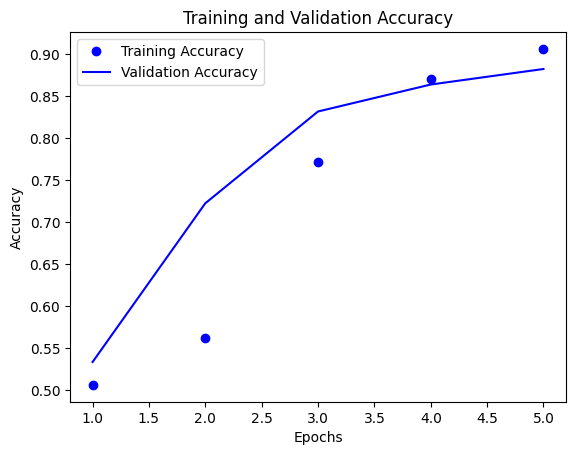

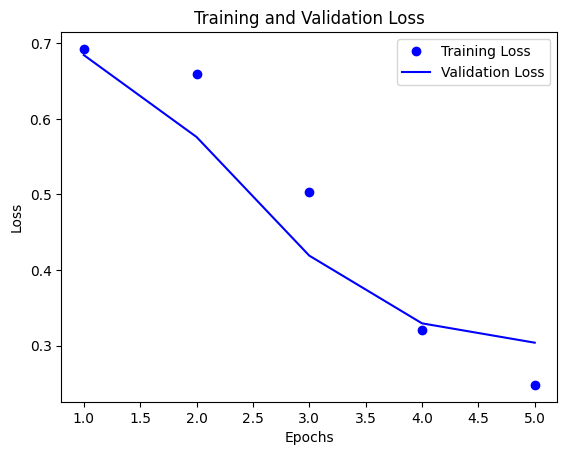

In [ ]:
# Visualising model training history
import matplotlib.pyplot as plt

history_dict=history.history
print("Keys available in history object:",history_dict.keys())
acc=history_dict['accuracy']
val_acc=history_dict['val_accuracy']
loss=history_dict['loss']
val_loss=history_dict['val_loss']

epochs=range(1,len(acc)+1)

plt.Figure(figsize=(12,6))
plt.plot(epochs, acc, 'bo', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.Figure(figsize=(12,6))
plt.plot(epochs, loss, 'bo', label="Training Loss")
plt.plot(epochs, val_loss, 'b', label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [ ]:
#Evaluate LSTM Model and Compare with Baseline
final_loss, final_accuracy=model.evaluate(X_test_padded, y_test_final, verbose=2)
print(f"Loss: {final_loss:.4f}")
print(f"Accuracy: {final_accuracy:.4f} ({(final_accuracy * 100):.2f}%)")



313/313 - 14s - 44ms/step - accuracy: 0.8821 - loss: 0.3038
Loss: 0.3038
Accuracy: 0.8821 (88.21%)


In [ ]:
y_pred_probs=model.predict(X_test_padded)

y_pred_lstm=[1 if prob>5 else 0 for prob in y_pred_probs.flatten()]

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


LSTM Model classification report
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67      5000
    Positive       0.00      0.00      0.00      5000

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000

LSTM Model confusion matrix


c:\Users\Varad Dalvi\Documents\Sentiment analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varad Dalvi\Documents\Sentiment analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Varad Dalvi\Documents\Sentiment analysis\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

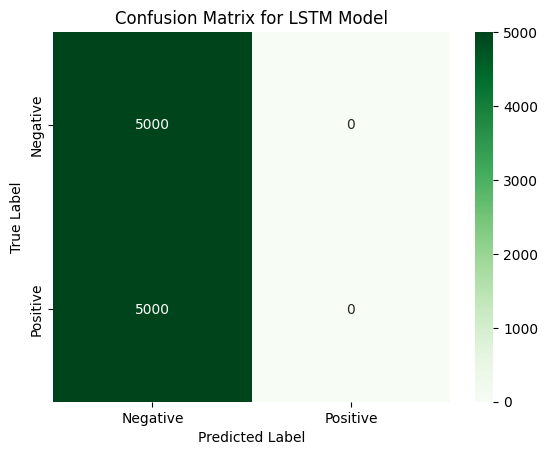

In [ ]:
print("LSTM Model classification report")
print(classification_report(y_test_final, y_pred_lstm, target_names=['Negative', 'Positive']))

print("LSTM Model confusion matrix")
cm_lstm=confusion_matrix(y_test_final, y_pred_lstm)
class_names=['Negative', 'Positive']

plt.Figure(figsize=(6,5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LSTM Model')
plt.show()